# Data transformations

In this document we will examine how the models transform the data, before proceeding to the multiclass classification task. Also, we will compare t-SNE and UMAP data visualizations. The models that will be used will be a Transformer and a LSTM. For the data visualization, we will use t-SNE and UMAP.

## Dataset and tools loading
Loading the required libraries and datasets needed to train and test the models.

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from torcheval.metrics import MulticlassAccuracy
import sys
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from utils import dataset_utils
from utils import train_test_utils as ttutils
from utils.models import MyTransformerModel, MyLSTMClassifier

from IPython.utils.io import capture_output

print(sys.path)

def load_config(file_path):
    with open(file_path, "r") as file:
        json_data = json.load(file)
        config = json_data["config"]
    return config

dataset_file = "/mnt/btrfs/datasets/cybersecurity/multiclass/cybersecurity-unified-multiclass.csv"
dataset_name = os.path.basename(dataset_file).split(".")[0]
lstm_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_lstm_{dataset_name}.pt")
lstm_removed_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_lstm_{dataset_name}_removed.pt")
transformer_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_transformer_{dataset_name}.pt")
transformer_removed_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_transformer_{dataset_name}_removed.pt")

rows_limit = 250e+3
chunk_size = 3e+6
DEVICE = ttutils.get_device()
TRANSFORMER_EPOCHS = 45
LSTM_EPOCHS = 10

with capture_output():
    csv_dataset = dataset_utils.CSVDataset(dataset_file, "Label", columns_to_drop=["Timestamp"], chunk_size=chunk_size)
    csv_dataset.load(rows_limit=rows_limit)

features, category_map, n_classes = csv_dataset.features, csv_dataset.categories, csv_dataset.n_classes
dataset_df = pd.DataFrame(csv_dataset.X.numpy(), columns=csv_dataset.features, dtype="float32")
dataset_df["Label"] = csv_dataset.y.numpy()
y = csv_dataset.y
X = csv_dataset.X
del csv_dataset

dataset_lstm_removed_df = dataset_df.drop(columns=["Fwd Seg Size Min", "Label"])
dataset_transformer_removed_df = dataset_df.drop(columns=["Src IP", "Dst IP", "Idle Mean", "Idle Min", "Idle Max", "Label"])
X_lstm_removed = torch.from_numpy(dataset_lstm_removed_df.to_numpy(dtype="float32"))
X_transformer_removed = torch.from_numpy(dataset_transformer_removed_df.to_numpy(dtype="float32"))
del dataset_lstm_removed_df, dataset_transformer_removed_df

print(category_map)
print(X.shape, X_lstm_removed.shape, X_transformer_removed.shape)
dataset = TensorDataset(X,y)
dataset_lstm_removed = TensorDataset(X_lstm_removed, y)
dataset_transformer_removed = TensorDataset(X_transformer_removed, y)

del X, X_lstm_removed, X_transformer_removed, y
dataset_df


['/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/ray/thirdparty_files', '/usr/lib64/python313.zip', '/usr/lib64/python3.13', '/usr/lib64/python3.13/lib-dynload', '', '/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages', '/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib/python3.13/site-packages', '/tmp/tmp25laa1dl', '/home/sbaltsas/Visual_Studio_Code_Projects/thesis']
CUDA available! GPU device name is: NVIDIA GeForce RTX 4060
{0: 'Botnet', 1: 'DoS', 2: 'MITM', 3: 'Normal', 4: 'Scanner', 5: 'Brute force', 6: 'Generic', 7: 'Exploit', 8: 'Infection'}
torch.Size([150903, 81]) torch.Size([150903, 80]) torch.Size([150903, 76])


,Src IP,Src Port,Dst IP,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3.232261e+09,17832.0,3.309940e+09,37215.0,6.0,5.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,3.232261e+09,17832.0,7.021389e+08,37215.0,6.0,1.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,3.232261e+09,17832.0,6.914280e+08,37215.0,6.0,2.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,3.232261e+09,17832.0,7.034514e+08,37215.0,6.0,2.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,3.232261e+09,17832.0,3.313908e+09,37215.0,6.0,6.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150898,3.232236e+09,54836.0,3.232236e+09,52869.0,6.0,9262464.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,9262464.0,0.0,9262464.0,9262464.0,8
150899,3.232236e+09,54776.0,3.115957e+09,52869.0,6.0,11419273.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,11419273.0,0.0,11419273.0,11419273.0,8
150900,3.232236e+09,32239.0,1.527684e+09,52869.0,6.0,11298387.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,11298387.0,0.0,11298387.0,11298387.0,8
150901,3.232236e+09,54836.0,3.119709e+09,52869.0,6.0,1995.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8


## Training models and data transformation

In order to visualize the data transformation of the best model, we need to train the model first on the 90% of the dataset. The rest 10% will be used for visualization needs.

### Training
#### Transformer

In [41]:
transformer_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_transformer", "best_config_multiclass.json")
config = load_config(transformer_config_file)
learning_rate = config.pop("lr")
batch_size = config.pop("batch_size")
transformer_hyperparameters = config
enc_embed_dim = config["enc_embedding_dim"]
transformer_model = MyTransformerModel(dataset.tensors[0].shape[1], n_classes, **transformer_hyperparameters)

transformer_removed_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_removed_features_transformer", "improved_removed_features_best_config.json")
config = load_config(transformer_removed_config_file)
learning_removed_rate = config.pop("lr")
batch_removed_size = config.pop("batch_size")
transformer_removed_hyperparameters = config
enc_embed_dim_removed = config["enc_embedding_dim"]
transformer_removed_model = MyTransformerModel(dataset_transformer_removed.tensors[0].shape[1], n_classes, **transformer_removed_hyperparameters)

# training transformer with all network specific features included
train_data, test_data = random_split(dataset, [0.9, 0.1])
train_loader = DataLoader(train_data, batch_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
transformer_model.to(DEVICE)
ttutils.train_model(transformer_model, transformer_model_file, train_loader, None, metric=train_metric, learning_rate=learning_rate, epochs=TRANSFORMER_EPOCHS)

Epoch 1/45. Average train accuracy: 51.222%, average loss: 1.26215, current loss: 1.84827.
Saved model!
Epoch 2/45. Average train accuracy: 57.243%, average loss: 1.07219, current loss: 1.16925.
Saved model!
Epoch 3/45. Average train accuracy: 58.772%, average loss: 1.03388, current loss: 1.53662.
Saved model!
Epoch 4/45. Average train accuracy: 60.431%, average loss: 1.00025, current loss: 0.72595.
Saved model!
Epoch 5/45. Average train accuracy: 61.314%, average loss: 0.97868, current loss: 1.65466.
Saved model!
Epoch 6/45. Average train accuracy: 62.161%, average loss: 0.95644, current loss: 0.45419.
Saved model!
Epoch 7/45. Average train accuracy: 63.163%, average loss: 0.92605, current loss: 1.81875.
Saved model!
Epoch 8/45. Average train accuracy: 63.657%, average loss: 0.90182, current loss: 0.99518.
Saved model!
Epoch 9/45. Average train accuracy: 64.377%, average loss: 0.87501, current loss: 0.67002.
Saved model!
Epoch 10/45. Average train accuracy: 64.936%, average loss: 0.85

In [27]:
# training transformer with removed network specific features
train_removed_data, test_removed_data = random_split(dataset_transformer_removed, [0.9, 0.1])
train_loader = DataLoader(train_removed_data, batch_removed_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
transformer_removed_model.to(DEVICE)
ttutils.train_model(transformer_removed_model, transformer_removed_model_file, train_loader, None, metric=train_metric, 
                    learning_rate=learning_removed_rate, epochs=TRANSFORMER_EPOCHS)

Epoch 1/45. Average train accuracy: 80.585%, average loss: 0.51929, current loss: 0.16646.
Saved model!
Epoch 2/45. Average train accuracy: 88.917%, average loss: 0.29769, current loss: 0.36455.
Saved model!
Epoch 3/45. Average train accuracy: 90.133%, average loss: 0.25870, current loss: 0.14421.
Saved model!
Epoch 4/45. Average train accuracy: 90.364%, average loss: 0.24955, current loss: 0.16505.
Saved model!
Epoch 5/45. Average train accuracy: 90.163%, average loss: 0.25656, current loss: 0.22813.
Epoch 6/45. Average train accuracy: 90.997%, average loss: 0.22804, current loss: 0.23499.
Saved model!
Epoch 7/45. Average train accuracy: 91.194%, average loss: 0.22265, current loss: 0.23747.
Saved model!
Epoch 8/45. Average train accuracy: 90.837%, average loss: 0.23596, current loss: 0.19914.
Epoch 9/45. Average train accuracy: 91.422%, average loss: 0.21383, current loss: 0.23683.
Saved model!
Epoch 10/45. Average train accuracy: 91.537%, average loss: 0.20910, current loss: 0.15191

### Inference and data transformation
#### Transformer - all network specific features included

KL divergence: 0.46707791090011597
0 (0,          t-sne_1    t-sne_2  Label
0      35.308292  65.678253      0
30     23.674950  58.425114      0
36    -95.186707 -19.722303      0
51    -78.359520  48.896484      0
55     29.158342  67.641586      0
...          ...        ...    ...
15038 -65.335320 -14.588936      0
15052  44.365829  49.734177      0
15063 -64.195358  42.193821      0
15078 -56.633842  27.243687      0
15079 -78.211784 -45.779972      0

[1684 rows x 3 columns])
1 (1,          t-sne_1    t-sne_2  Label
2     -34.107864  54.186703      1
4      -2.005775  92.946541      1
7     -34.134995  55.739773      1
8      -2.622644 -53.804737      1
14    -76.449089 -14.285391      1
...          ...        ...    ...
15044 -74.898918 -36.865696      1
15050 -82.037933  30.077377      1
15051  -5.024349  48.162357      1
15080 -83.184059   1.187856      1
15085  22.192425  66.242691      1

[1686 rows x 3 columns])
2 (2,          t-sne_1     t-sne_2  Label
12    -81.615486  -

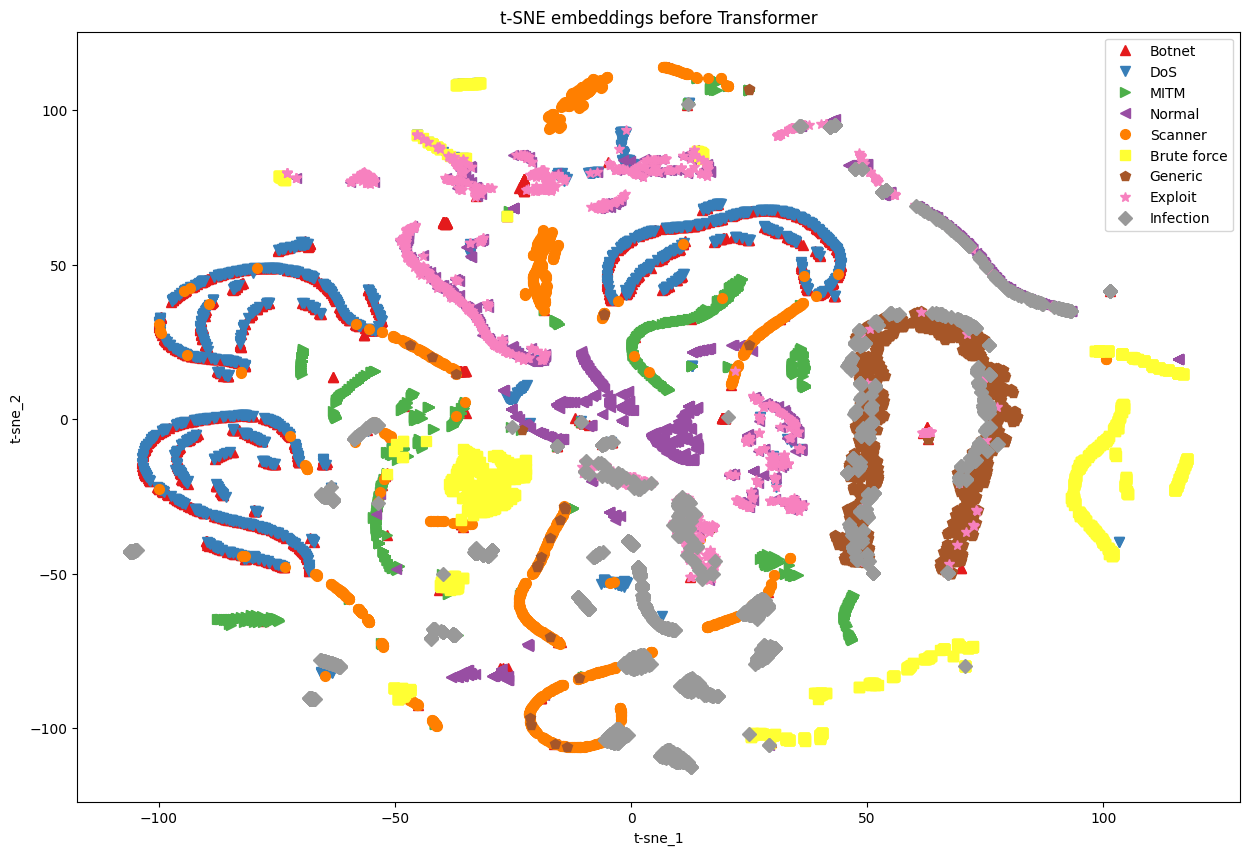

In [73]:
umap_reducer = umap.UMAP(n_components=2, n_neighbors=20, n_jobs=-1, min_dist=0.2)
tsne_reducer = TSNE(n_components=2, perplexity=30, method="barnes_hut", n_jobs=-1)

X_test, y_test = test_data.dataset[test_data.indices][0], test_data.dataset[test_data.indices][1]
embedding = tsne_reducer.fit_transform(X_test)
print("KL divergence:", tsne_reducer.kl_divergence_)
embedding.shape

def plot_embedding(embedding, y_test, reducer_type="umap", title="plot"):
    import matplotlib as mpl
    colors = mpl.colormaps["Set1"].colors[:n_classes]
    markers = ("^", "v", ">", "<", "o", "s", "p", "*", "D")
    df = pd.DataFrame(embedding, columns=[f"{reducer_type}_1", f"{reducer_type}_2"])
    df["Label"] = y_test
    df.shape
    groups = df.groupby("Label")
    fig = plt.figure(figsize=((15,10)))
    ax = fig.add_subplot()
    for i, group in enumerate(groups):
        name, group_data = group
        print(name, group)
        ax.plot(group_data[f"{reducer_type}_1"], group_data[f"{reducer_type}_2"], marker=markers[i], 
                color=colors[i], linestyle='', label=category_map[name], markersize=7)
    ax.legend()
    ax.set_xlabel(f"{reducer_type}_1")
    ax.set_ylabel(f"{reducer_type}_2")
    ax.set_title(title)
    plt.show()

plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings before Transformer")


81
KL divergence: 0.5924513339996338
0 (0,          t-sne_1    t-sne_2  Label
0      97.373093 -39.244274      0
30     84.374802 -33.923729      0
36     -0.882836 -98.748398      0
51     46.657383  77.969627      0
55     92.280579 -44.018303      0
...          ...        ...    ...
15038  17.438065 -79.896538      0
15052  93.661308 -21.985693      0
15063  37.083477  91.955132      0
15078  20.907928  93.448166      0
15079 -17.249714 -94.265305      0

[1684 rows x 3 columns])
1 (1,          t-sne_1    t-sne_2  Label
2     -24.974901 -30.675913      1
4     -30.622076 -64.471115      1
7     -27.498493 -30.145313      1
8       1.969096   1.722411      1
14     11.225240 -75.038246      1
...          ...        ...    ...
15044 -15.153348 -78.334106      1
15050  31.616261  74.935844      1
15051  54.314980 -37.179104      1
15080  27.365841 -90.715515      1
15085  85.047005 -46.065643      1

[1686 rows x 3 columns])
2 (2,           t-sne_1    t-sne_2  Label
12       0.508202

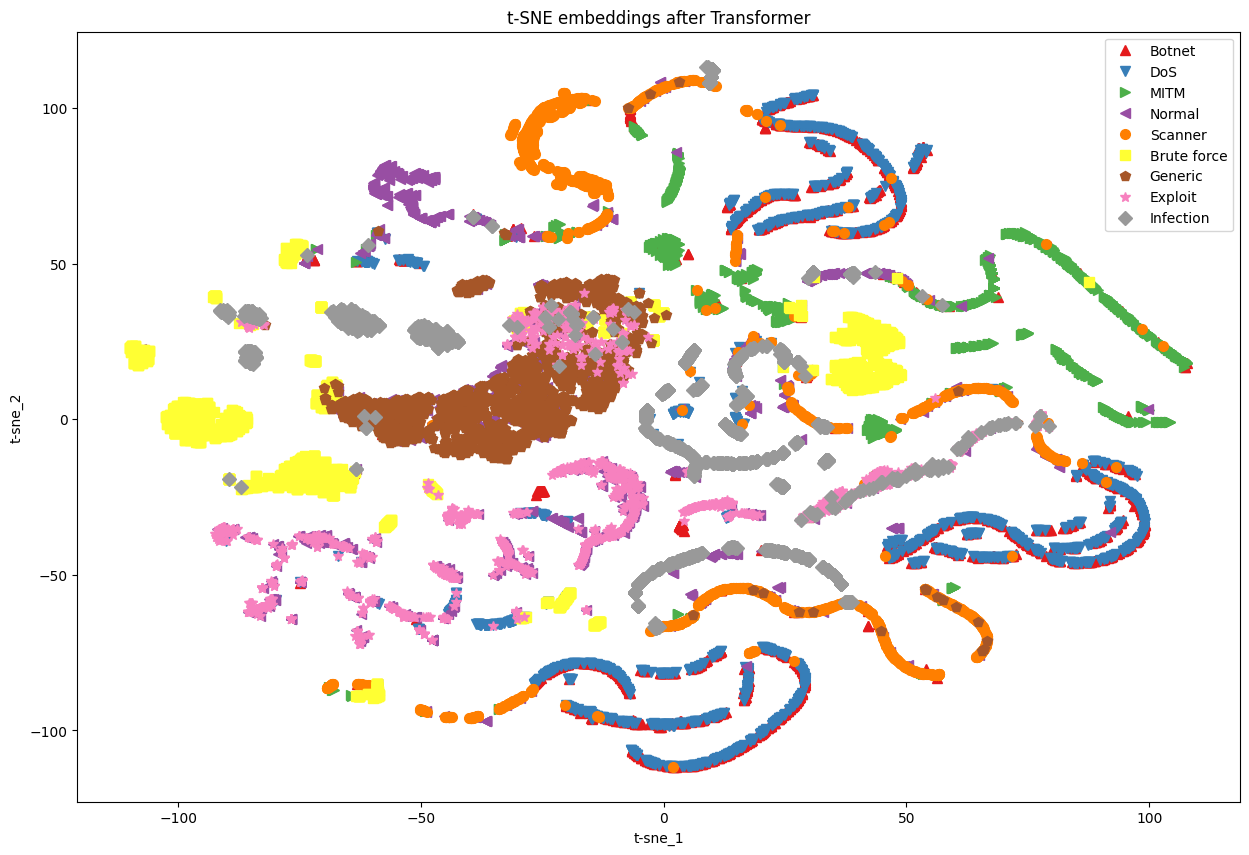

In [74]:
tsne_reducer = TSNE(n_components=2, perplexity=30, method="barnes_hut", n_jobs=-1)
transformer_model = MyTransformerModel(X_test.shape[1], n_classes, **transformer_hyperparameters).to(DEVICE)
transformer_model.load_state_dict(torch.load(transformer_model_file, weights_only=True))
transformer_model.eval()
transformer_output = torch.empty((X_test.shape[0], 64), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_data, batch_size=batch_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        transformer_output[offset:offset+n] = transformer_model.transformer_layers(data)
        offset += n
assert offset == transformer_output.shape[0]

transformer_output = transformer_output.to("cpu")
embedding = tsne_reducer.fit_transform(transformer_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after Transformer")

#### Transformer - network specific features removed separatively

KL divergence: -0.34924864768981934
0 (0,          t-sne_1    t-sne_2  Label
13    -68.972404 -94.511826      0
15    -71.982384  42.044025      0
20    -77.997101  88.178513      0
39    -71.982384  42.044025      0
42     17.041996  16.261147      0
...          ...        ...    ...
15034 -80.396378  87.965569      0
15038 -71.982384  42.044025      0
15056 -71.982384  42.044025      0
15062 -71.982384  42.044025      0
15078 -71.982384  42.044025      0

[1669 rows x 3 columns])
1 (1,          t-sne_1    t-sne_2  Label
4     -71.982384  42.044025      1
12     -1.958001 -54.196678      1
17    -71.982384  42.044025      1
45    -68.972404 -94.511826      1
52    -71.982384  42.044025      1
...          ...        ...    ...
15022  -5.388022  19.420282      1
15023  17.369766 -85.982086      1
15029 -71.982384  42.044025      1
15051 -71.982384  42.044025      1
15055  14.977879 -86.300514      1

[1723 rows x 3 columns])
2 (2,          t-sne_1     t-sne_2  Label
0      50.316689  

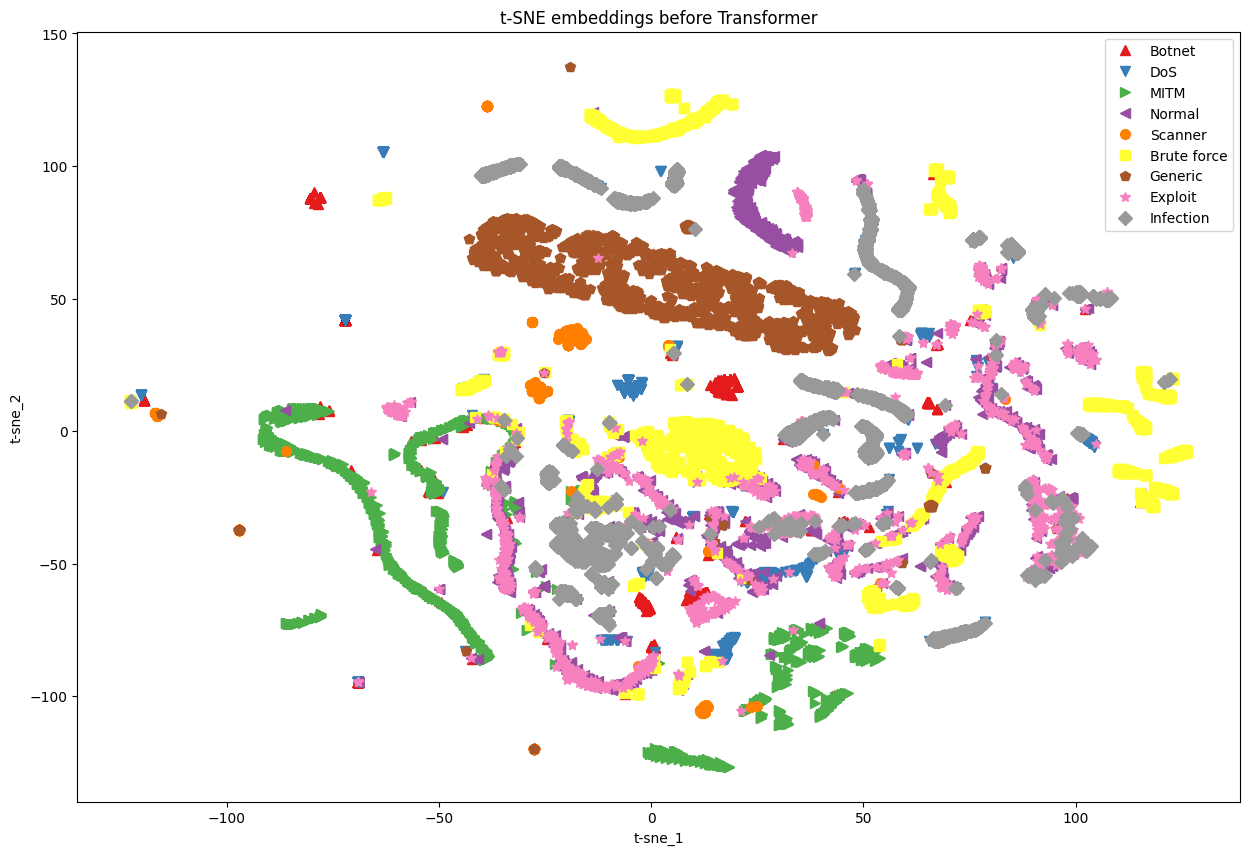

In [75]:
tsne_reducer = TSNE(n_components=2, perplexity=30, method="barnes_hut", n_jobs=-1)
X_test, y_test = test_removed_data.dataset[test_removed_data.indices][0], test_removed_data.dataset[test_removed_data.indices][1]
embedding = tsne_reducer.fit_transform(X_test)
print("KL divergence:", tsne_reducer.kl_divergence_)
embedding.shape
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings before Transformer")

76
KL divergence: 0.3511260151863098
0 (0,           t-sne_1    t-sne_2  Label
13      54.294022  16.304243      0
15     107.979370 -20.318832      0
20      46.917690 -23.976007      0
39     107.979370 -20.318832      0
42      49.658924 -75.124771      0
...           ...        ...    ...
15034   44.673302 -25.844286      0
15038   76.570786  37.606655      0
15056   76.570786  37.606655      0
15062   76.570786  37.606655      0
15078   76.570786  37.606655      0

[1669 rows x 3 columns])
1 (1,          t-sne_1    t-sne_2  Label
4      75.048317  -5.771688      1
12     14.905329 -53.666626      1
17     75.048317  -5.771688      1
45     54.462711  -0.686483      1
52     75.048317  -5.771688      1
...          ...        ...    ...
15022  25.543045 -97.411316      1
15023  22.396992 -32.079502      1
15029  87.606651 -66.767136      1
15051  87.606651 -66.767136      1
15055  23.887970 -30.157013      1

[1723 rows x 3 columns])
2 (2,          t-sne_1    t-sne_2  Label
0     

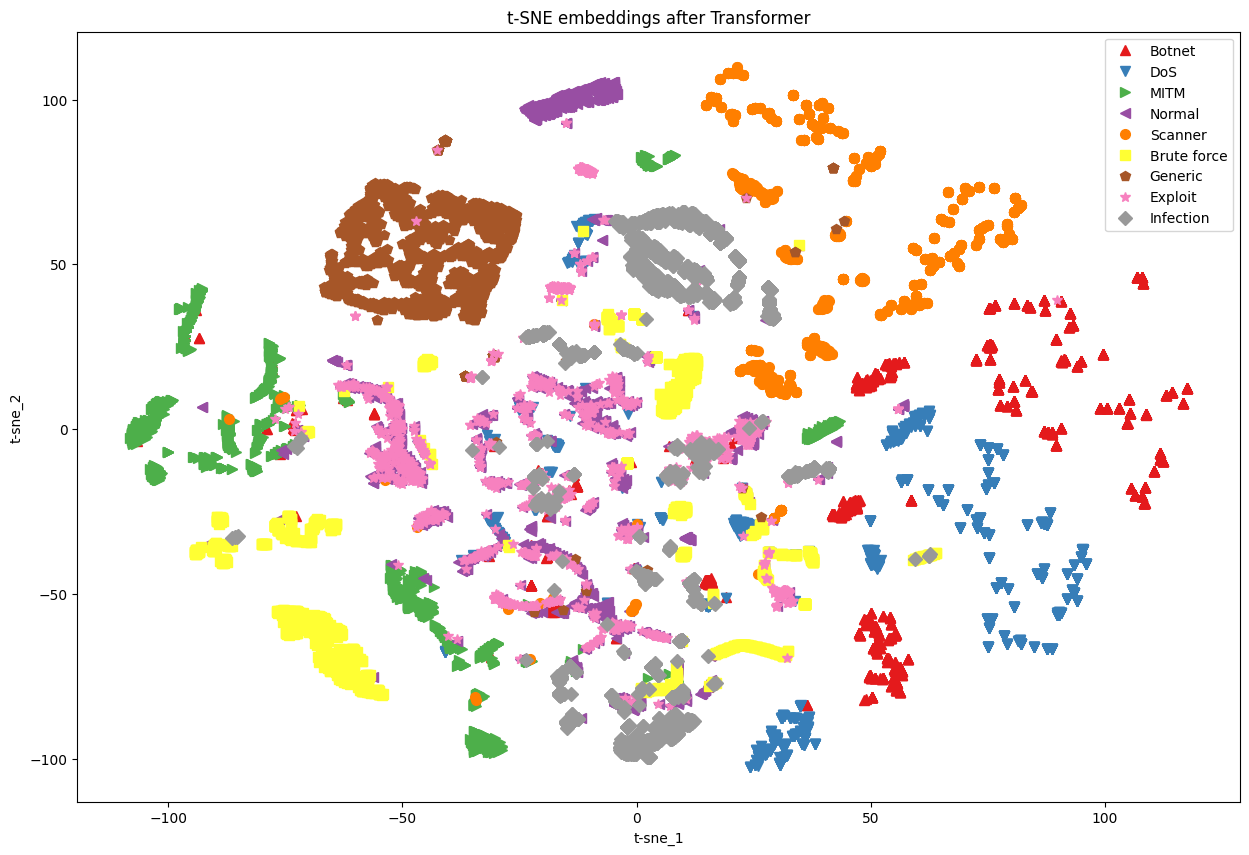

In [79]:
tsne_reducer = TSNE(n_components=2, perplexity=40, method="barnes_hut", n_jobs=-1)
transformer_model = MyTransformerModel(X_test.shape[1], n_classes, **transformer_removed_hyperparameters).to(DEVICE)
transformer_model.load_state_dict(torch.load(transformer_removed_model_file, weights_only=True))
transformer_model.eval()
transformer_output = torch.empty((X_test.shape[0], 128), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_removed_data, batch_size=batch_removed_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        transformer_output[offset:offset+n] = transformer_model.transformer_layers(data)
        offset += n
assert offset == transformer_output.shape[0]

transformer_output = transformer_output.to("cpu")
embedding = tsne_reducer.fit_transform(transformer_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after Transformer")